# Neural Implicit Representation — Visual Experiments

> **Goal:** *Build* coordinate-based neural representations and watch the core claims of the theory become tangible — that a small MLP **is** a signal, why a naive MLP comes out blurry (**spectral bias**), how **Fourier features** and **SIREN** fix it, why the representation is **resolution-free**, how a surface is a **zero-level set**, and how a **latent code** turns one decoder into a whole family of shapes.

Instead of 3D (hard to render compactly), we use a **2D signal** — an image and 2D signed-distance fields — which carries every lesson and plots cleanly. We implement everything in PyTorch and train it for real.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **The MLP is the signal** | Can a coordinate MLP store an image in its weights? |
| 2 | **Spectral bias** | Why is a plain MLP blurry, and how do Fourier features / SIREN fix it? |
| 3 | **Resolution-free** | Why can we query the trained network at *any* resolution? |
| 4 | **Surface = zero-level set** | How does an implicit field encode a shape boundary? |
| 5 | **Latent-conditioned shapes** | How does one decoder + a latent code morph between shapes? |

---
**Linked theory:** `research/01-neural-implicit-representation.md`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. torch', torch.__version__)

Setup complete. torch 2.12.0+cpu


---
## A shared toolkit: coordinate grids, encodings, and networks

We define the building blocks once.

- **Coordinate grid** — the inputs of an INR are *coordinates* in $[-1,1]^2$, not pixels.
- **Fourier features** — map a coordinate to a bank of sines/cosines at many frequencies, $\gamma(x)=[\sin(2\pi Bx),\cos(2\pi Bx)]$, to defeat spectral bias (Tancik et al., 2020).
- **Plain MLP** — a ReLU coordinate network (the naive baseline).
- **SIREN** — an MLP with $\sin$ activations and the special initialization from Sitzmann et al. (2020).

The same `train` loop fits any of them by minimizing reconstruction MSE — exactly the per-signal optimization the theory describes.

In [2]:
def coord_grid(res):
    """Return (coords [res*res,2] in [-1,1]) and the meshgrid (X, Y) for reshaping."""
    xs = np.linspace(-1, 1, res)
    X, Y = np.meshgrid(xs, xs)
    coords = np.stack([X.ravel(), Y.ravel()], axis=1).astype(np.float32)
    return torch.tensor(coords), (X, Y)


class FourierFeatures:
    """Gaussian random Fourier feature mapping (Tancik et al., 2020)."""
    def __init__(self, in_dim=2, mapping_size=64, scale=6.0, seed=0):
        g = torch.Generator().manual_seed(seed)
        self.B = torch.randn(mapping_size, in_dim, generator=g) * scale
        self.out_dim = 2 * mapping_size

    def __call__(self, x):
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)


def make_mlp(in_dim, hidden=256, layers=3, out=1):
    mods = [nn.Linear(in_dim, hidden), nn.ReLU()]
    for _ in range(layers - 1):
        mods += [nn.Linear(hidden, hidden), nn.ReLU()]
    mods += [nn.Linear(hidden, out)]
    return nn.Sequential(*mods)


class SIREN(nn.Module):
    """Sinusoidal representation network with the Sitzmann et al. (2020) init."""
    def __init__(self, in_dim=2, hidden=256, layers=3, out=1, w0=30.0):
        super().__init__()
        self.w0 = w0
        dims = [in_dim] + [hidden] * layers
        self.linears = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(layers)])
        self.final = nn.Linear(hidden, out)
        with torch.no_grad():
            for i, lin in enumerate(self.linears):
                fan = lin.weight.shape[1]
                if i == 0:
                    lin.weight.uniform_(-1 / fan, 1 / fan)              # first layer
                else:
                    b = np.sqrt(6 / fan) / w0
                    lin.weight.uniform_(-b, b)
            fan = self.final.weight.shape[1]
            self.final.weight.uniform_(-np.sqrt(6 / fan) / w0, np.sqrt(6 / fan) / w0)

    def forward(self, x):
        for i, lin in enumerate(self.linears):
            x = torch.sin(self.w0 * lin(x))
        return self.final(x)


def train(model, X, target, steps=1200, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = F.mse_loss(model(X), target)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


def radial_spectrum(img2d):
    """Radially-averaged magnitude spectrum: how much energy at each spatial frequency."""
    F2 = np.abs(np.fft.fftshift(np.fft.fft2(img2d)))
    h, w = img2d.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.indices((h, w))
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(int)
    tbin = np.bincount(r.ravel(), F2.ravel())
    nr = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)

print('Toolkit ready.')

Toolkit ready.


---
## Experiment 1: The MLP *is* the signal

**Question:** The central idea of an implicit representation: a signal is not stored as a grid of values but as the **weights of a function** $f_\theta(x,y)\to\text{value}$. Can a small coordinate MLP actually absorb an image into its parameters, and how does its size compare to the pixel grid?

We build a target image with deliberately mixed content — a smooth central glow (low frequency), vertical stripes (mid frequency), and a hard-edged square (high frequency) — then fit a plain ReLU MLP that maps $(x,y)$ to brightness.

In [3]:
np.random.seed(1)
torch.manual_seed(1)

RES = 64
coords, (X, Y) = coord_grid(RES)

# target image: smooth glow + stripes + hard square edge
r = np.sqrt(X ** 2 + Y ** 2)
glow = np.exp(-(r / 0.5) ** 2)
stripes = 0.5 + 0.5 * np.sin(2 * np.pi * 6 * X)
square = ((np.abs(X) < 0.45) & (np.abs(Y) < 0.45)).astype(float)
img = 0.45 * glow + 0.30 * stripes * (r < 0.95) + 0.25 * square
img = (img - img.min()) / (img.max() - img.min())
target = torch.tensor(img.ravel().astype(np.float32)).unsqueeze(1)

# fit a plain ReLU coordinate MLP
plain = make_mlp(in_dim=2, hidden=256, layers=3, out=1)
loss_plain = train(plain, coords, target, steps=1500, lr=1e-3, seed=1)
with torch.no_grad():
    rec_plain = plain(coords).numpy().reshape(RES, RES)

n_params = sum(p.numel() for p in plain.parameters())
print(f'image pixels         : {RES * RES}')
print(f'MLP parameters       : {n_params}')
print(f'final reconstruction MSE: {loss_plain[-1]:.5f}')

image pixels         : 4096
MLP parameters       : 132609
final reconstruction MSE: 0.00540


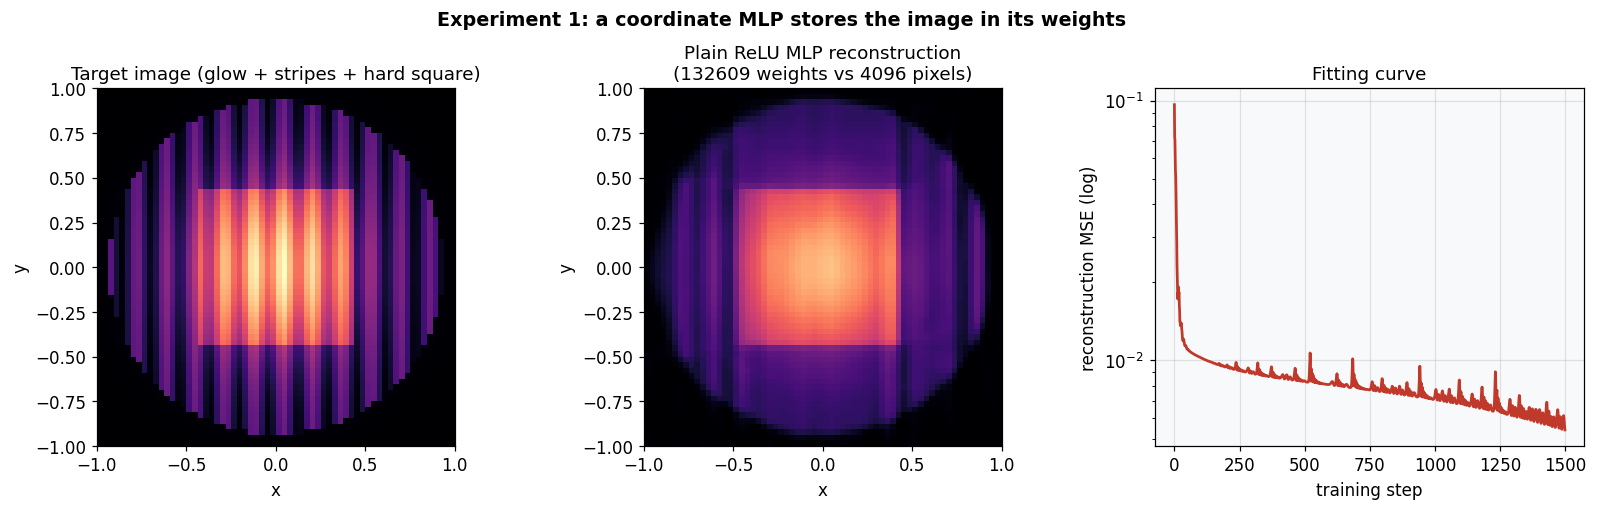

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))
fig.suptitle('Experiment 1: a coordinate MLP stores the image in its weights',
             fontsize=12.5, fontweight='bold')

ax = axes[0]
im = ax.imshow(img, extent=[-1, 1, -1, 1], origin='lower', cmap='magma')
ax.set_title('Target image (glow + stripes + hard square)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(False)

ax2 = axes[1]
ax2.imshow(rec_plain, extent=[-1, 1, -1, 1], origin='lower', cmap='magma', vmin=0, vmax=1)
ax2.set_title(f'Plain ReLU MLP reconstruction\n({n_params} weights vs {RES*RES} pixels)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.grid(False)

ax3 = axes[2]
ax3.plot(loss_plain, color='#c0392b', lw=1.8)
ax3.set_yscale('log')
ax3.set_xlabel('training step'); ax3.set_ylabel('reconstruction MSE (log)')
ax3.set_title('Fitting curve')
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The plain MLP captures the overall layout — the central glow and the gross position of the square — but the reconstruction is visibly **soft**: the stripes are washed out and the square's edges are smeared. The loss drops fast then plateaus.

2. **Why it looks this way:** After training, the image lives entirely in the network's weights — querying $f_\theta(x,y)$ at every grid point regenerates it, no pixel array stored. The network is a *continuous function*, so the representation is decoupled from any grid. But a plain ReLU MLP has a strong low-frequency preference, so the sharp, high-frequency parts come out blurred.

3. **Key takeaway:** "The network is the signal" is literal — but a naive coordinate MLP is a *low-pass* version of the signal. That blur is not a training bug; it is **spectral bias**, which the next experiment dissects and cures.

---
## Experiment 2: Spectral bias — and how Fourier features / SIREN cure it

**Question:** The research file names the central failure mode of coordinate MLPs: **spectral bias**, the tendency to fit low frequencies and ignore high ones. Two standard fixes are **Fourier feature** encodings and **SIREN** (sine activations). Do they actually recover the high-frequency detail, and can we *measure* it in the frequency domain?

We fit the same image with three networks — plain ReLU (from Exp 1), Fourier-feature MLP, and SIREN — then compare reconstructions and their radially-averaged power spectra against the target's.

In [5]:
np.random.seed(2)
torch.manual_seed(2)

# Fourier-feature MLP
ff = FourierFeatures(in_dim=2, mapping_size=64, scale=6.0, seed=0)
feats = ff(coords)
fourier_mlp = make_mlp(in_dim=ff.out_dim, hidden=256, layers=3, out=1)
loss_fourier = train(fourier_mlp, feats, target, steps=1500, lr=1e-3, seed=2)
with torch.no_grad():
    rec_fourier = fourier_mlp(feats).numpy().reshape(RES, RES)

# SIREN
siren = SIREN(in_dim=2, hidden=256, layers=3, out=1, w0=30.0)
loss_siren = train(siren, coords, target, steps=1500, lr=1e-3, seed=2)
with torch.no_grad():
    rec_siren = siren(coords).numpy().reshape(RES, RES)

# radial spectra
sp_target = radial_spectrum(img)
sp_plain = radial_spectrum(rec_plain)
sp_fourier = radial_spectrum(rec_fourier)
sp_siren = radial_spectrum(rec_siren)

print('final reconstruction MSE (scientific notation):')
print(f'  plain ReLU : {loss_plain[-1]:.2e}')
print(f'  Fourier    : {loss_fourier[-1]:.2e}')
print(f'  SIREN      : {loss_siren[-1]:.2e}')
print(f'-> Fourier is ~{loss_plain[-1] / loss_fourier[-1]:.0f}x lower MSE than plain ReLU')

final reconstruction MSE (scientific notation):
  plain ReLU : 5.40e-03
  Fourier    : 7.86e-09
  SIREN      : 8.74e-07
-> Fourier is ~687566x lower MSE than plain ReLU


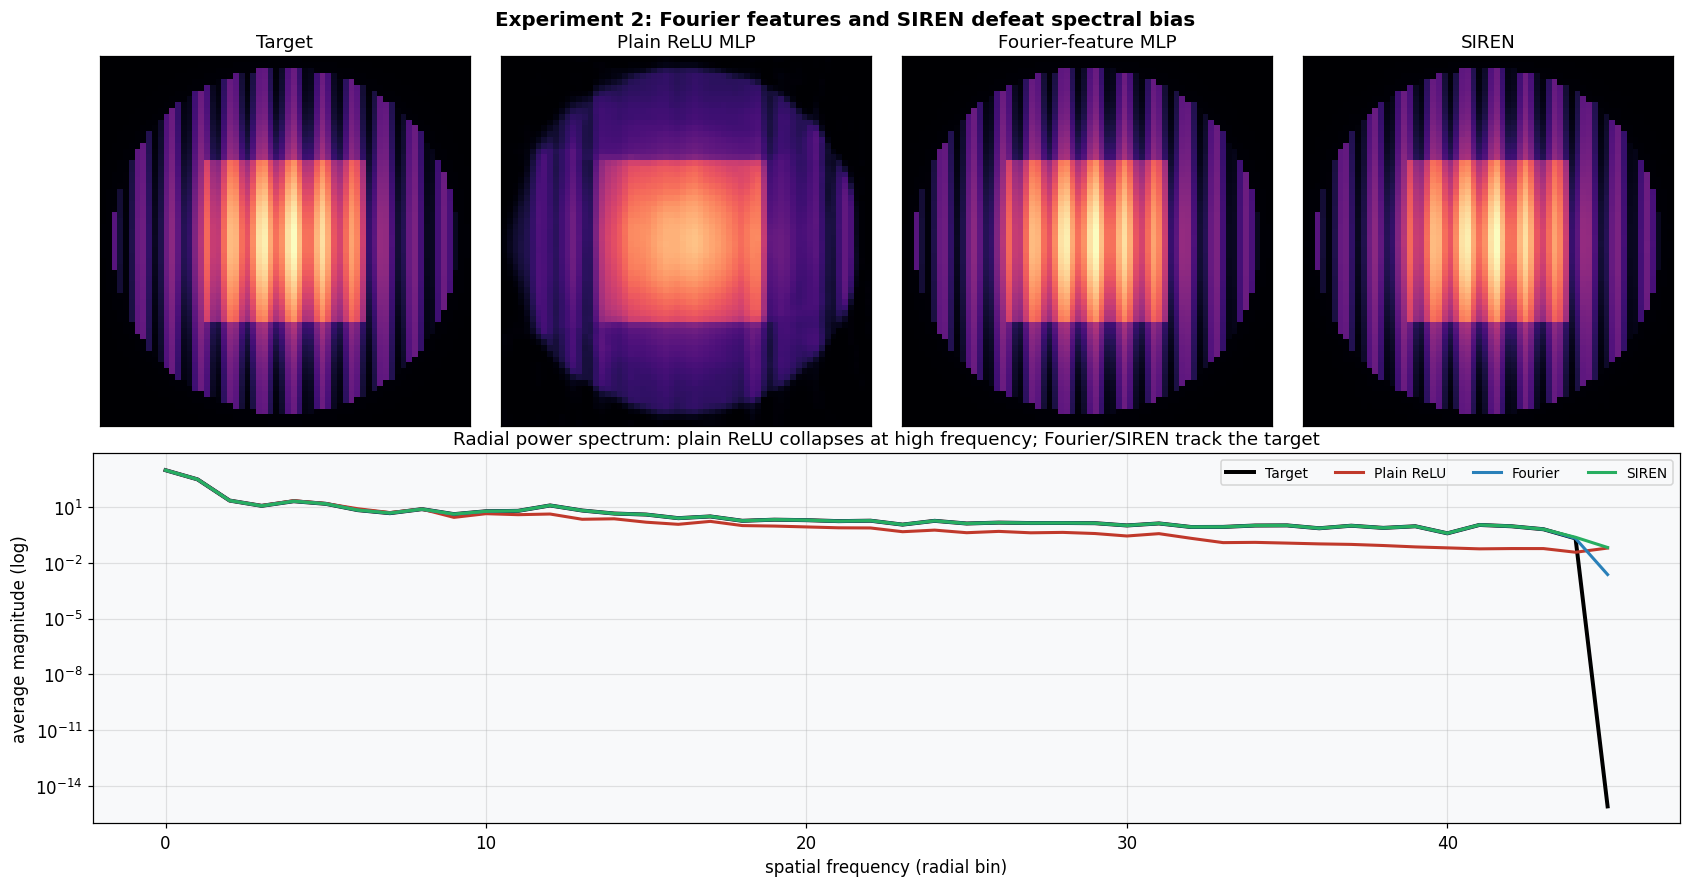

In [6]:
fig = plt.figure(figsize=(15.5, 8.2))
fig.suptitle('Experiment 2: Fourier features and SIREN defeat spectral bias',
             fontsize=13, fontweight='bold')

titles = ['Target', 'Plain ReLU MLP', 'Fourier-feature MLP', 'SIREN']
imgs = [img, rec_plain, rec_fourier, rec_siren]
for k, (t, im_k) in enumerate(zip(titles, imgs)):
    ax = fig.add_subplot(2, 4, k + 1)
    ax.imshow(np.clip(im_k, 0, 1), extent=[-1, 1, -1, 1], origin='lower', cmap='magma', vmin=0, vmax=1)
    ax.set_title(t); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

# bottom-left: radial power spectra
axs = fig.add_subplot(2, 1, 2)
freqs = np.arange(len(sp_target))
axs.semilogy(freqs, sp_target, color='black', lw=2.6, label='Target')
axs.semilogy(freqs, sp_plain, color='#c0392b', lw=2.0, label='Plain ReLU')
axs.semilogy(freqs, sp_fourier, color='#2980b9', lw=2.0, label='Fourier')
axs.semilogy(freqs, sp_siren, color='#27ae60', lw=2.0, label='SIREN')
axs.set_xlabel('spatial frequency (radial bin)')
axs.set_ylabel('average magnitude (log)')
axs.set_title('Radial power spectrum: plain ReLU collapses at high frequency; Fourier/SIREN track the target')
axs.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Top row — the plain ReLU reconstruction is soft, while the Fourier-feature and SIREN reconstructions render the stripes and the square's crisp edges faithfully, at a far lower MSE. Bottom — the radial power spectrum makes the cause explicit: the plain MLP's curve (red) **falls away from the target at high frequencies**, whereas Fourier (blue) and SIREN (green) stay glued to the black target curve across the whole band.

2. **Why it looks this way:** A plain ReLU network has a strong low-frequency inductive bias, so high-frequency detail is the last thing it learns — and within a fixed budget it mostly never does. Fourier features pre-expand the coordinates into many sinusoids, handing the MLP high-frequency basis functions to combine; SIREN bakes the sinusoids into the activations themselves. Either way the network gains direct access to the high-frequency subspace.

3. **Key takeaway:** Spectral bias is the single most important practical fact about coordinate networks. The fix — sinusoidal encodings or activations — is exactly what makes NeRF and other neural fields able to render sharp detail, which is why the next item in this tier (NeRF) leans on positional encoding.

---
## Experiment 3: Resolution-free — query at any resolution

**Question:** Because an INR is a *continuous function* of coordinates, it is not tied to the grid it was trained on. After training the Fourier model on a $64\times64$ grid, can we evaluate it on a denser grid to get a genuinely higher-resolution image — and how does that compare to naively upsampling the discrete $64\times64$ output?

We query the **already-trained** Fourier network on a $256\times256$ grid and compare against nearest-neighbour upsampling of the low-res reconstruction.

In [7]:
HI = 256
coords_hi, (Xh, Yh) = coord_grid(HI)
with torch.no_grad():
    rec_hi = fourier_mlp(ff(coords_hi)).numpy().reshape(HI, HI)

# naive nearest-neighbour upsampling of the 64x64 reconstruction for comparison
rep = HI // RES
rec_nn = np.kron(rec_fourier, np.ones((rep, rep)))

# zoom window around the square's corner to see the difference
def crop(a):
    n = a.shape[0]
    lo, hi = int(0.55 * n), int(0.85 * n)
    return a[lo:hi, lo:hi]

print(f'trained grid : {RES} x {RES}')
print(f'queried grid : {HI} x {HI}  (same weights, no retraining)')

trained grid : 64 x 64
queried grid : 256 x 256  (same weights, no retraining)


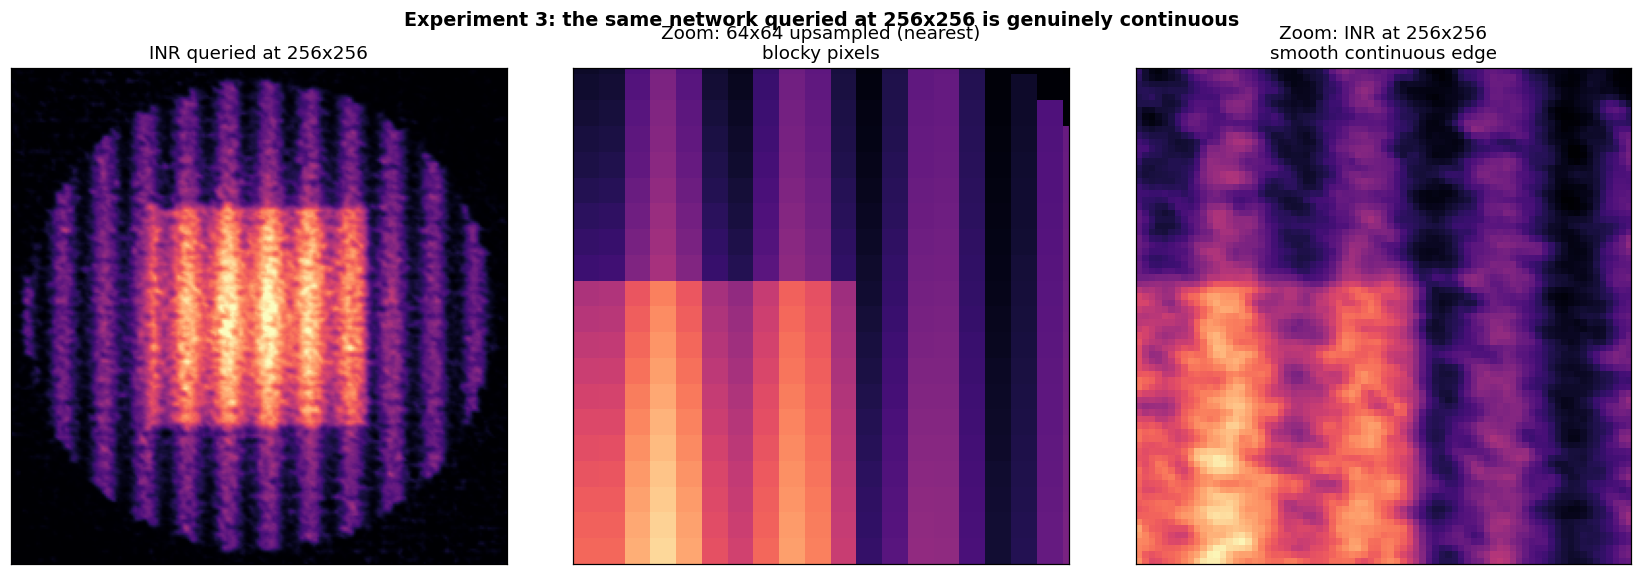

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.3))
fig.suptitle('Experiment 3: the same network queried at 256x256 is genuinely continuous',
             fontsize=12.5, fontweight='bold')

ax = axes[0]
ax.imshow(np.clip(rec_hi, 0, 1), extent=[-1, 1, -1, 1], origin='lower', cmap='magma', vmin=0, vmax=1)
ax.set_title('INR queried at 256x256'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

ax2 = axes[1]
ax2.imshow(np.clip(crop(rec_nn), 0, 1), origin='lower', cmap='magma', vmin=0, vmax=1)
ax2.set_title('Zoom: 64x64 upsampled (nearest)\nblocky pixels'); ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)

ax3 = axes[2]
ax3.imshow(np.clip(crop(rec_hi), 0, 1), origin='lower', cmap='magma', vmin=0, vmax=1)
ax3.set_title('Zoom: INR at 256x256\nsmooth continuous edge'); ax3.set_xticks([]); ax3.set_yticks([]); ax3.grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Evaluating the trained network on a $256\times256$ grid produces a clean high-resolution image. Zooming into the square's corner, the naive upsampling of the $64\times64$ output is **blocky** (it just repeats pixels), while the INR query gives a **smooth, continuously-defined edge** — new detail that was never an explicit pixel.

2. **Why it looks this way:** The network stores a function, not samples. Asking for a denser grid simply evaluates $f_\theta$ at more points; between the original training coordinates the function interpolates *in its own learned way*, not by copying pixels. Memory is decoupled from resolution — the same weights serve any output size.

3. **Key takeaway:** Resolution-independence is the practical superpower of implicit representations and the reason they beat voxel grids on memory: detail is bounded by network capacity, not by a stored array. This is exactly the property that lets a NeRF render novel high-resolution views from a fixed-size MLP.

---
## Experiment 4: A surface is a zero-level set

**Question:** For geometry, an INR usually regresses a **signed distance field (SDF)** or occupancy, and the shape is the **zero-level set** $\{x : f_\theta(x)=0\}$ (DeepSDF, Occupancy Networks). Can a coordinate network learn a 2D signed-distance field whose zero contour reproduces a target shape?

We build the exact signed-distance field of a peanut shape (the union of two disks), fit a Fourier-feature MLP to it, and extract the learned zero contour.

In [9]:
np.random.seed(4)
torch.manual_seed(4)

RES_S = 96
coords_s, (Xs, Ys) = coord_grid(RES_S)

# ground-truth implicit field: union of two disks -> negative inside, zero on the boundary
def disk_sdf(X, Y, cx, cy, rad):
    return np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) - rad

sdf_true = np.minimum(disk_sdf(Xs, Ys, -0.28, 0.0, 0.42),
                      disk_sdf(Xs, Ys, 0.28, 0.0, 0.42))
sdf_target = torch.tensor(sdf_true.ravel().astype(np.float32)).unsqueeze(1)

ff_s = FourierFeatures(in_dim=2, mapping_size=64, scale=4.0, seed=1)
feats_s = ff_s(coords_s)
sdf_net = make_mlp(in_dim=ff_s.out_dim, hidden=256, layers=3, out=1)
loss_sdf = train(sdf_net, feats_s, sdf_target, steps=1500, lr=1e-3, seed=4)
with torch.no_grad():
    sdf_pred = sdf_net(feats_s).numpy().reshape(RES_S, RES_S)

print(f'final SDF regression MSE: {loss_sdf[-1]:.2e}')

final SDF regression MSE: 3.81e-08


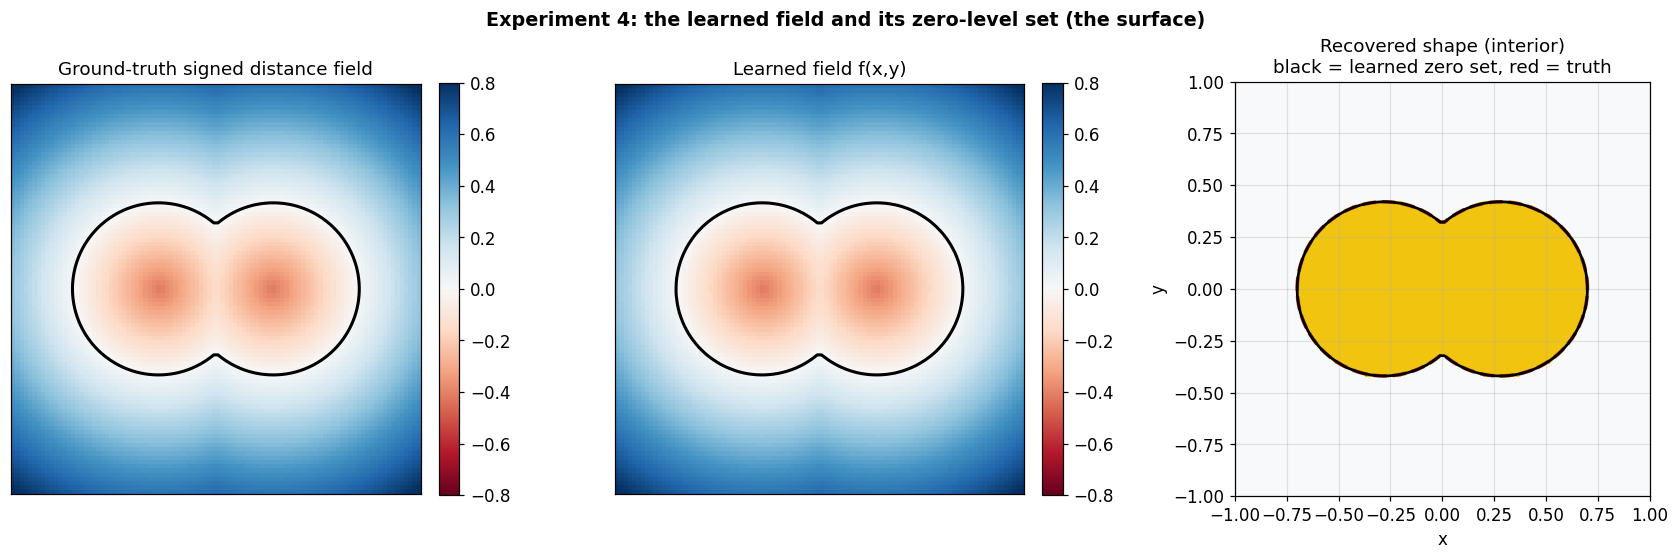

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.0))
fig.suptitle('Experiment 4: the learned field and its zero-level set (the surface)',
             fontsize=12.5, fontweight='bold')

ext = [-1, 1, -1, 1]
ax = axes[0]
c0 = ax.imshow(sdf_true, extent=ext, origin='lower', cmap='RdBu', vmin=-0.8, vmax=0.8)
ax.contour(Xs, Ys, sdf_true, levels=[0], colors='black', linewidths=2)
ax.set_title('Ground-truth signed distance field'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(c0, ax=ax, fraction=0.046, pad=0.04)

ax2 = axes[1]
c1 = ax2.imshow(sdf_pred, extent=ext, origin='lower', cmap='RdBu', vmin=-0.8, vmax=0.8)
ax2.contour(Xs, Ys, sdf_pred, levels=[0], colors='black', linewidths=2)
ax2.set_title('Learned field f(x,y)'); ax2.set_xticks([]); ax2.set_yticks([]); ax2.grid(False)
fig.colorbar(c1, ax=ax2, fraction=0.046, pad=0.04)

ax3 = axes[2]
ax3.contourf(Xs, Ys, (sdf_pred < 0).astype(float), levels=[0.5, 1.5], colors=['#f1c40f'])
ax3.contour(Xs, Ys, sdf_true, levels=[0], colors='#c0392b', linewidths=2.4, linestyles='--')
ax3.contour(Xs, Ys, sdf_pred, levels=[0], colors='black', linewidths=1.8)
ax3.set_aspect('equal')
ax3.set_title('Recovered shape (interior)\nblack = learned zero set, red = truth')
ax3.set_xlabel('x'); ax3.set_ylabel('y')
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The learned field (middle) reproduces the ground-truth signed-distance field (left) — blue inside, red outside, near-zero on the boundary. Extracting the zero contour and the interior (right) gives back the peanut shape, with the learned zero set (black) sitting right on the true boundary (red dashed).

2. **Why it looks this way:** The network never stored the shape's outline; it learned a *scalar field over all of space* whose sign flips across the boundary. The geometry is implicit — it emerges only when we ask "where is $f_\theta = 0$?". Because the field is continuous, the boundary can be extracted at any resolution (the 2D analogue of running Marching Cubes on a 3D SDF).

3. **Key takeaway:** Representing a surface as the zero-level set of a learned function is what lets a single MLP encode arbitrary, even changing, topology without a mesh — the foundation of DeepSDF and Occupancy Networks, and the geometric half of what NeRF's density field does.

---
## Experiment 5: One decoder, many shapes — latent conditioning

**Question:** A single MLP encodes one shape. The research file's bridge to latent space: **condition** the function on a latent code, $f_\theta(x,y,\mathbf{z})$, so one network represents a whole *family* and moving in $\mathbf{z}$ morphs the shape. We train this as an **auto-decoder** (DeepSDF-style: no encoder, the per-shape codes are optimized jointly with the weights). Does interpolating the latent code produce smooth, valid in-between shapes?

We fit three shapes that are the unit balls of three norms — a **circle** ($L_2$), a **diamond** ($L_1$), and a **square** ($L_\infty$) — each with its own learnable latent, then decode shapes along an interpolation path through the latent space.

In [11]:
np.random.seed(5)
torch.manual_seed(5)

RES_C = 64
coords_c, (Xc, Yc) = coord_grid(RES_C)
ff_c = FourierFeatures(in_dim=2, mapping_size=64, scale=4.0, seed=2)
feats_c = ff_c(coords_c)
N = feats_c.shape[0]
RAD = 0.6

# three implicit fields = unit balls of L2, L1, Linf norms (signed: negative inside)
fields = [
    np.sqrt(Xc ** 2 + Yc ** 2) - RAD,              # circle  (L2)
    (np.abs(Xc) + np.abs(Yc)) - RAD,               # diamond (L1)
    np.maximum(np.abs(Xc), np.abs(Yc)) - RAD,      # square  (Linf)
]
shape_names = ['circle (L2)', 'diamond (L1)', 'square (Linf)']
targets_c = [torch.tensor(f.ravel().astype(np.float32)).unsqueeze(1) for f in fields]

# auto-decoder: learnable latent per shape + a shared conditioned MLP
LD = 16
latents = nn.Parameter(torch.randn(3, LD) * 0.1)
cond_mlp = make_mlp(in_dim=ff_c.out_dim + LD, hidden=256, layers=3, out=1)

opt = torch.optim.Adam(list(cond_mlp.parameters()) + [latents], lr=1e-3)
loss_hist = []
for step in range(2500):
    opt.zero_grad()
    loss = 0.0
    for i in range(3):
        zin = latents[i].unsqueeze(0).expand(N, -1)
        pred = cond_mlp(torch.cat([feats_c, zin], dim=1))
        loss = loss + F.mse_loss(pred, targets_c[i])
    loss = loss / 3
    loss.backward()
    opt.step()
    loss_hist.append(loss.item())

def decode_latent(z):
    with torch.no_grad():
        zin = z.unsqueeze(0).expand(N, -1)
        return cond_mlp(torch.cat([feats_c, zin], dim=1)).numpy().reshape(RES_C, RES_C)

print(f'final auto-decoder MSE over 3 shapes: {loss_hist[-1]:.6f}')

final auto-decoder MSE over 3 shapes: 0.000019


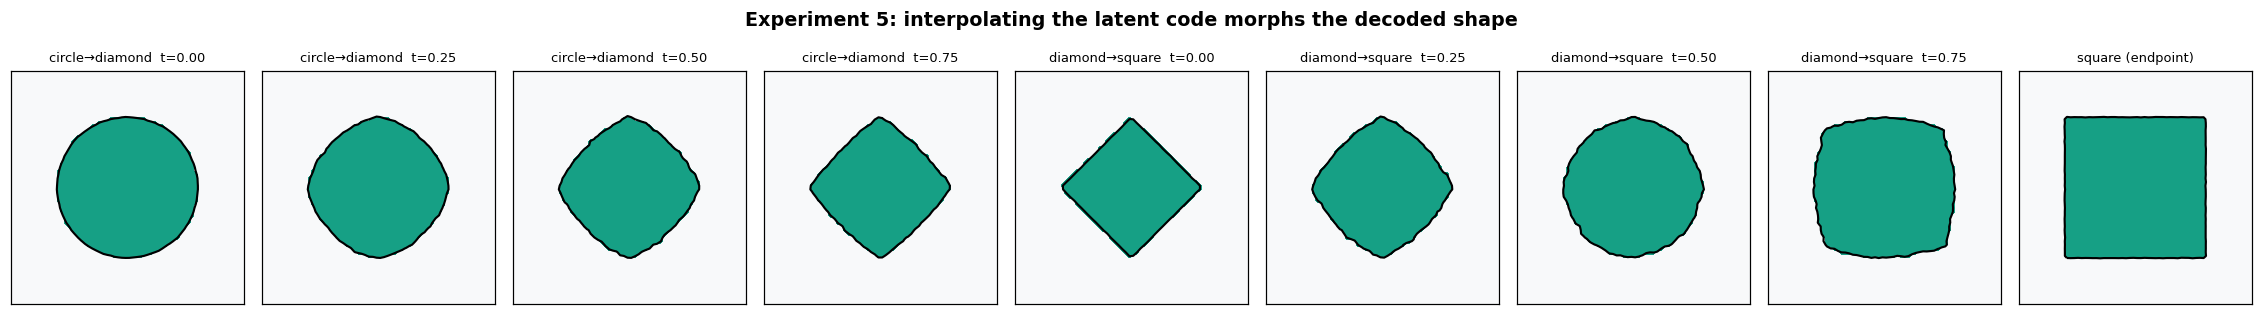

In [12]:
# interpolation path: circle -> diamond -> square (linear in latent space)
frames = []
labels = []
for a, b in [(0, 1), (1, 2)]:
    for t in np.linspace(0, 1, 4, endpoint=False):
        z = (1 - t) * latents[a].detach() + t * latents[b].detach()
        frames.append(decode_latent(z))
        labels.append(f'{shape_names[a].split()[0]}\u2192{shape_names[b].split()[0]}  t={t:.2f}')
frames.append(decode_latent(latents[2].detach()))
labels.append('square (endpoint)')

fig, axes = plt.subplots(1, len(frames), figsize=(2.3 * len(frames), 3.0))
fig.suptitle('Experiment 5: interpolating the latent code morphs the decoded shape',
             fontsize=12.5, fontweight='bold')
for ax, fr, lab in zip(axes, frames, labels):
    ax.contourf(Xc, Yc, (fr < 0).astype(float), levels=[0.5, 1.5], colors=['#16a085'])
    ax.contour(Xc, Yc, fr, levels=[0], colors='black', linewidths=1.4)
    ax.set_aspect('equal'); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_title(lab, fontsize=8.5); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The three endpoint shapes (circle, diamond, square) are all rendered by **one** network, distinguished only by their latent code. Sliding the latent from the circle's code toward the diamond's and then the square's produces a smooth sequence of valid intermediate shapes — corners gradually emerging and sharpening.

2. **Why it looks this way:** The auto-decoder forces a *shared* function $f_\theta(x,y,\mathbf{z})$ to explain all three fields, so the latent code becomes the knob that selects which shape to decode. Because the decoder is smooth in $\mathbf{z}$, codes *between* the trained ones decode to coherent in-between geometry — the network has organized a small shape manifold inside its latent space.

3. **Key takeaway:** This is the exact bridge to the rest of Latent-Anything: a geometry becomes **a point in a latent space**, the decoder (MLP + level-set extraction or, for NeRF, volume rendering) is deterministic, and every latent operation from earlier tiers — interpolation, [slerp](../../03-geometry-structure/research/05-slerp.md), arithmetic — now acts on *shapes*.

---
## Summary

| Experiment | Theme | Key insight |
|---|---|---|
| 1. MLP is the signal | Concept | A coordinate MLP stores an image in its weights — a continuous function, not a grid |
| 2. Spectral bias | The core problem | Plain ReLU MLPs low-pass the signal; Fourier features / SIREN restore high frequencies |
| 3. Resolution-free | Why it scales | The trained function can be queried at any resolution; memory is decoupled from detail |
| 4. Zero-level set | Geometry | A surface is $\{x : f_\theta(x)=0\}$ of a learned field (DeepSDF / Occupancy Networks) |
| 5. Latent conditioning | Bridge to latent | One decoder + a latent code represents a whole shape family; interpolation morphs shapes |

### Connection to the broader theory

These experiments turn the definition of a neural implicit representation — *a signal as a coordinate function* — into something you can watch. Experiment 1 makes "the network is the signal" literal; Experiment 2 isolates **spectral bias**, the one fact that governs whether the representation is sharp, and shows the Fourier/SIREN cures that NeRF and friends depend on; Experiment 3 demonstrates the resolution-free continuity that beats voxel grids on memory; Experiment 4 shows geometry as a **zero-level set**; and Experiment 5 conditions the decoder on a **latent code**, turning a shape into a point in a latent space. That last step is the gateway to the rest of tier 3B: **NeRF** swaps the SDF/occupancy field for a density-plus-colour radiance field rendered by volume integration, and 3D Gaussian Splatting later trades the implicit MLP for an explicit, editable set of Gaussians — different latent designs for the same goal of putting a renderable 3D scene inside a latent space.